# UK Climate Data: Various Plots

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy.stats import linregress
import cartopy.feature as cfeature

# Use raw string (r'...') to avoid Windows path errors
FILE_PATH = r'C:\Users\James\Downloads\era5new.nc' 

# Configuration for all 10 variables
# keys must match the variable names in the processed dataset
VAR_CONFIG = {
    't2m':        {'type': 'avg', 'label': '2m Temperature (°C)', 'cmap': 'RdBu_r'},
    'tp':         {'type': 'sum', 'label': 'Total Precipitation (mm)', 'cmap': 'Blues'},
    'stl2':       {'type': 'avg', 'label': 'Soil Temp Level 2 (°C)', 'cmap': 'inferno'},
    'wind_speed': {'type': 'avg', 'label': '10m Wind Speed (m/s)', 'cmap': 'YlGnBu'},
    'd2m':        {'type': 'avg', 'label': 'Dewpoint Temperature (°C)', 'cmap': 'Greens'},
    'e':          {'type': 'sum', 'label': 'Total Evaporation (mm)', 'cmap': 'BrBG'},
    'ro':         {'type': 'sum', 'label': 'Runoff (mm)', 'cmap': 'PuBu'},
    'sf':         {'type': 'sum', 'label': 'Snowfall (mm water eq)', 'cmap': 'PuBuGn'},
    'swvl1':      {'type': 'avg', 'label': 'Volumetric Soil Water (m3/m3)', 'cmap': 'gist_earth_r'},
    'sp':         {'type': 'avg', 'label': 'Surface Pressure (hPa)', 'cmap': 'RdGy_r'},
}

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import linregress

def preprocess_dataset(ds):
    """
    Clean up time dimensions and calculate derived variables.
    """
    # 1. Fix Time Name (valid_time -> time)
    if 'valid_time' in ds.coords:
        ds = ds.rename({'valid_time': 'time'})
        print("Renamed 'valid_time' to 'time'.")
    
    # 2. Safe Wind Speed Calculation
    u_var = ds['u10'] if 'u10' in ds else ds['10u'] if '10u' in ds else None
    v_var = ds['v10'] if 'v10' in ds else ds['10v'] if '10v' in ds else None
    
    # Only calculate if found BOTH components
    if u_var is not None and v_var is not None:
        ds['wind_speed'] = np.sqrt(u_var**2 + v_var**2)
        print("Calculated Wind Speed from components.")
    else:
        print("Could not find U/V wind components. Skipping wind speed calc.")
    
    # 3. Pressure Conversion (Pa -> hPa)
    if 'sp' in ds:
        ds['sp'] = ds['sp'] / 100.0
        
    return ds

def get_processed_monthly_data(ds, var_name, config):
    """
    Cleans units and calculates monthly totals/averages.
    Retains the spatial and monthly dimensions for the histograms.
    """
    da = ds[var_name]
    
    # Exclude 2023 and 2024 entirely
    da = da.sel(time=~da.time.dt.year.isin([2023, 2024]))
    
    # --- TYPE: AVERAGE ---
    if config['type'] == 'avg':
        # Convert Kelvin to Celsius for Temperature variables (check mean > 200)
        if da.mean() > 200 and 'Pa' not in config['label']: 
            da = da - 273.15

    # --- TYPE: SUM ---
    elif config['type'] == 'sum':
        # Multiply rate by days in the specific month
        days_in_month = da.time.dt.days_in_month
        da = da * days_in_month
        
        # Convert meters to mm for water variables
        if 'mm' in config['label']:
             da = da * 1000
             
    return da

def plot_variable(ds, var_key):
    """
    Generates Map, Time Series with Line of Best Fit & Error Bars, and Histograms 
    for a single variable.
    """
    if var_key not in ds:
        print(f"Error: Variable '{var_key}' not found in dataset.")
        return

    config = VAR_CONFIG[var_key]
    print(f"\n==========================================")
    print(f"--- Plotting {config['label']} ---")
    
    # Get the processed monthly spatial data
    da_monthly = get_processed_monthly_data(ds, var_key, config)

    # --- 1. SPATIAL MAP (OVERALL MEAN) ---
    # Calculate the overall spatial mean across all valid months
    spatial_mean = da_monthly.mean(dim='time')

    # Calculate robust min and max
    vmin = float(spatial_mean.quantile(0.02))
    vmax = float(spatial_mean.quantile(0.98))

    # Get the colourmap, reverse for Evaporation
    cmap = config.get('cmap', 'viridis')
    if var_key == 'e' and not cmap.endswith('_r'):
        cmap += '_r'

    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    spatial_mean.plot(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, 
                      cbar_kwargs={'label': config['label']})
    
    ax.coastlines()
    if var_key == 'e':
        ax.add_feature(cfeature.OCEAN, zorder=2, facecolor='lightgray')
        
    ax.set_title(f"Climatological Mean (All Years): {config['label']}")
    plt.show()

    # --- 2. TIME SERIES ---
    # To keep the Annual Trend intact, calculate yearly values just for this plot
    if config['type'] == 'avg':
        da_yearly = da_monthly.groupby('time.year').mean(dim='time')
    elif config['type'] == 'sum':
        da_yearly = da_monthly.groupby('time.year').sum(dim='time')

    ts_mean = da_yearly.mean(dim=['latitude', 'longitude'])
    ts_std = da_yearly.std(dim=['latitude', 'longitude'])
    
    years = ts_mean.year.values
    means = ts_mean.values
    stds = ts_std.values
    
    valid_idx = ~np.isnan(means)
    years_valid = years[valid_idx]
    means_valid = means[valid_idx]
    stds_valid = stds[valid_idx]
    
    slope, intercept, r_value, p_value, std_err = linregress(years_valid, means_valid)
    best_fit_line = slope * years_valid + intercept
    z_score = slope / std_err if std_err != 0 else 0
    
    print(f"Trend (Slope): {slope:.4f} per year")
    print(f"Standard Error: {std_err:.4f}")
    print(f"Z-Score: {z_score:.2f} \t (Values > 1.96 or < -1.96 indicate >95% confidence)")
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.errorbar(years_valid, means_valid, yerr=stds_valid, fmt='o', color='black', 
                ecolor='gray', elinewidth=1, capsize=3, ms=4, 
                label='UK Mean $\pm$ 1 $\sigma$ (Spatial)')
    ax.plot(years_valid, best_fit_line, color='red', lw=2, linestyle='--', 
            label=f'Line of Best Fit (Z={z_score:.2f})')
    ax.set_title(f"Annual Trend: {config['label']}")
    ax.set_ylabel(config['label'])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()
    plt.show()

    # --- 3. HISTOGRAMS (all spatial cells, all months) ---
    # Slice into eras based on time
    pre_90 = da_monthly.sel(time=slice(None, '1989-12-31'))
    post_90 = da_monthly.sel(time=slice('1990-01-01', None))
    
    # Flatten arrays to get every single spatial/monthly data point
    pre_90_vals = pre_90.values.flatten()
    post_90_vals = post_90.values.flatten()
    
    # Drop NaNs (removes oceans)
    pre_90_vals = pre_90_vals[~np.isnan(pre_90_vals)]
    post_90_vals = post_90_vals[~np.isnan(post_90_vals)]
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Increased bins to 75
    data_min = min(pre_90_vals.min(), post_90_vals.min())
    data_max = max(pre_90_vals.max(), post_90_vals.max())
    bins = np.linspace(float(data_min), float(data_max), 75)
    
    # density=True ensures both histograms have an area of 1, despite different era lengths
    ax.hist(pre_90_vals, bins=bins, alpha=0.5, color='blue', label='Pre-1990', density=True)
    ax.hist(post_90_vals, bins=bins, alpha=0.5, color='red', label='Post-1990', density=True)
    
    ax.set_xlabel(config['label'])
    ax.set_ylabel('Density')
    ax.set_title(f"Distribution Shift: {config['label']}")
    ax.legend()
    plt.show()

In [3]:
# Open and process the dataset
ds_raw = xr.open_dataset(FILE_PATH)
ds = preprocess_dataset(ds_raw)
print("Dataset loaded and processed successfully.")
print("Available variables:", list(ds.data_vars))

Renamed 'valid_time' to 'time'.
Calculated Wind Speed from components.
Dataset loaded and processed successfully.
Available variables: ['d2m', 't2m', 'stl2', 'sf', 'swvl1', 'ro', 'e', 'u10', 'v10', 'sp', 'tp', 'wind_speed']


## Temperature


--- Plotting 2m Temperature (°C) ---


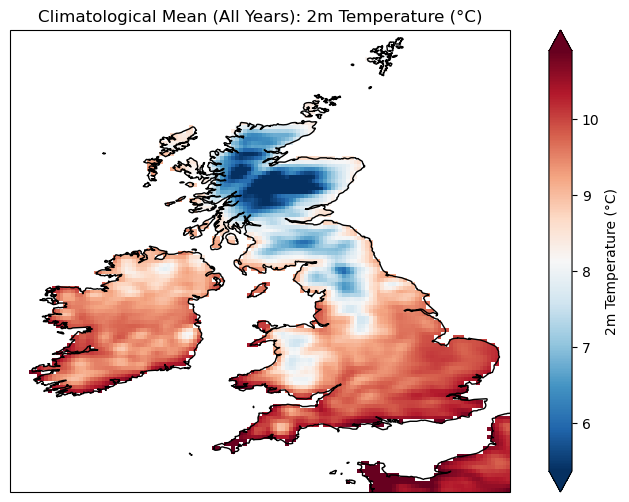

Trend (Slope): 0.0169 per year
Standard Error: 0.0025
Z-Score: 6.64 	 (Values > 1.96 or < -1.96 indicate >95% confidence)


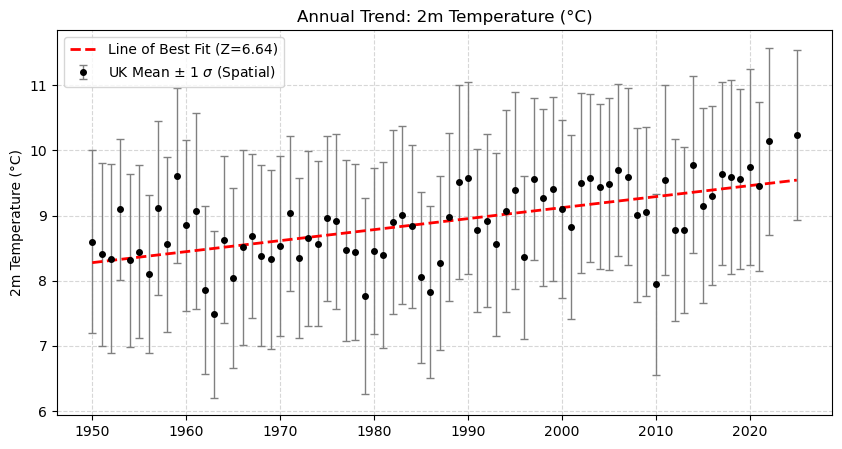

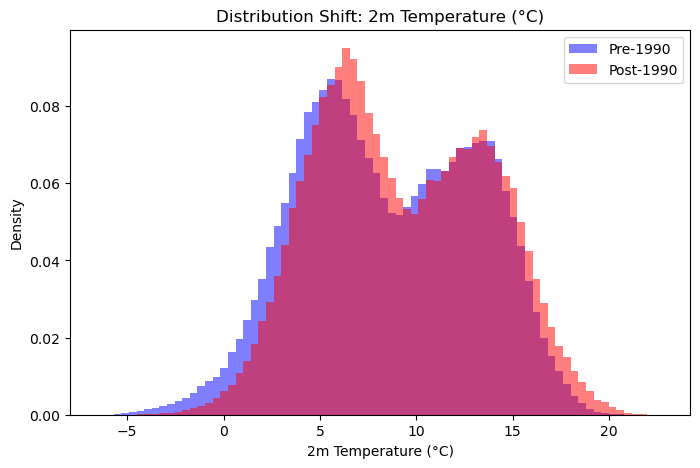

In [4]:
plot_variable(ds, 't2m')

## Precipitation


--- Plotting Total Precipitation (mm) ---


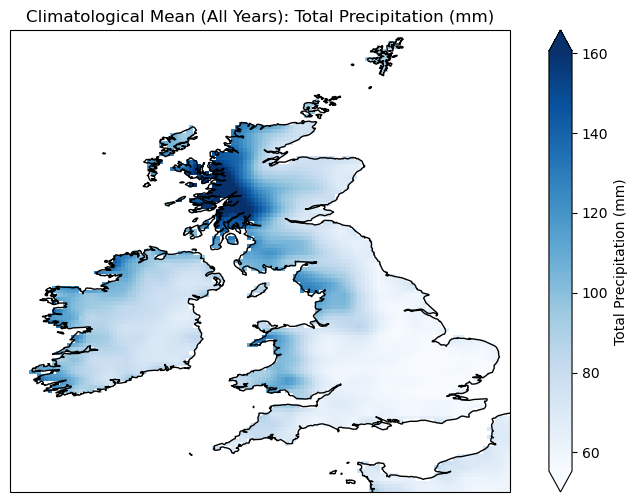

Trend (Slope): 0.6272 per year
Standard Error: 0.1552
Z-Score: 4.04 	 (Values > 1.96 or < -1.96 indicate >95% confidence)


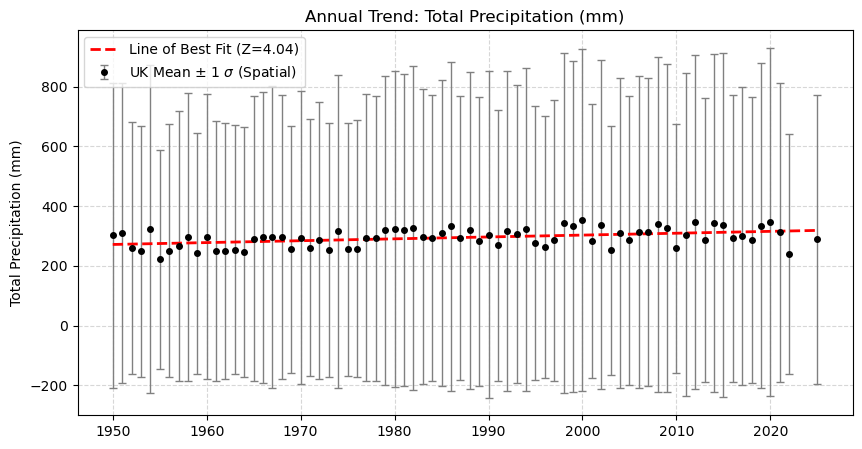

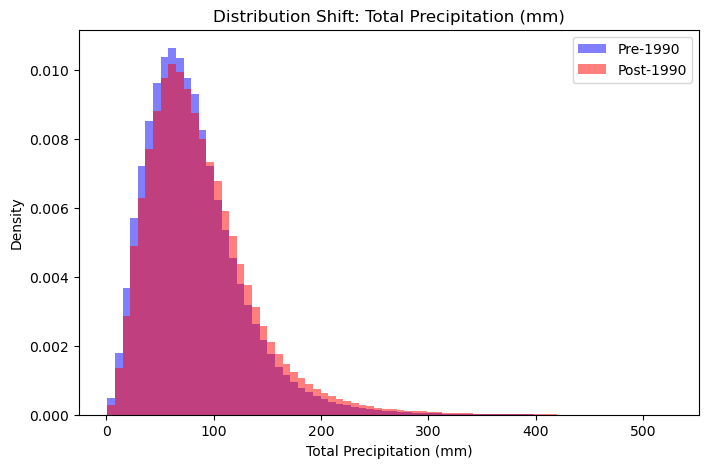

In [5]:
plot_variable(ds, 'tp')

## Soil Temperature (Level 2)


--- Plotting Soil Temp Level 2 (°C) ---


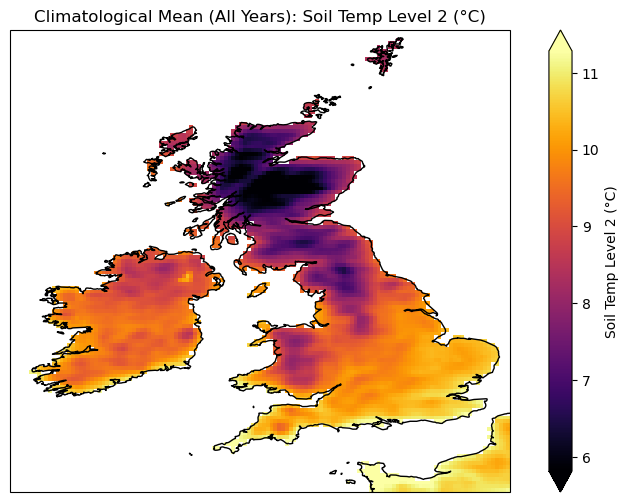

Trend (Slope): 0.0164 per year
Standard Error: 0.0025
Z-Score: 6.49 	 (Values > 1.96 or < -1.96 indicate >95% confidence)


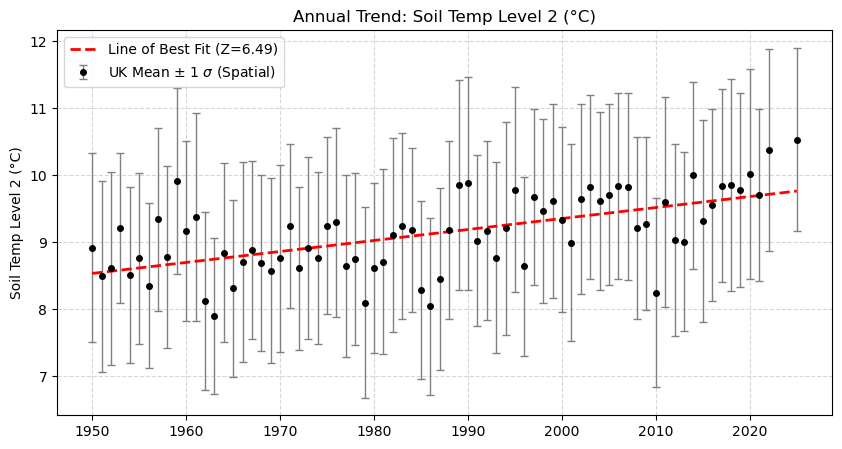

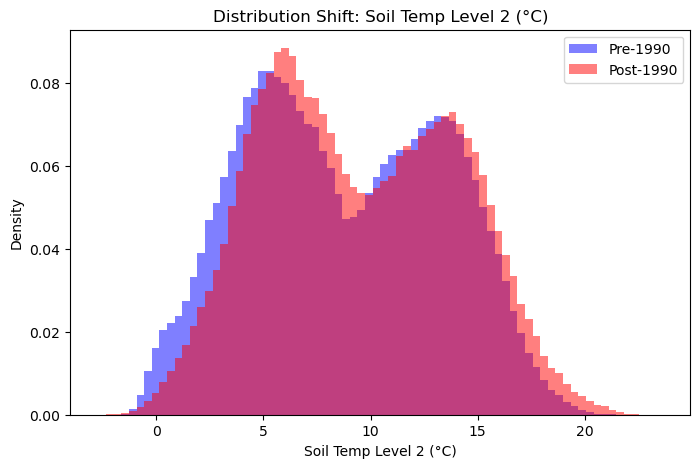

In [6]:
plot_variable(ds, 'stl2')

## Wind Speed


--- Plotting 10m Wind Speed (m/s) ---


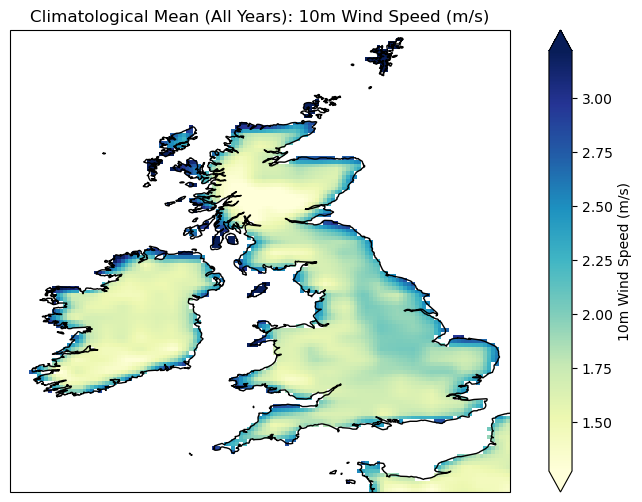

Trend (Slope): 0.0015 per year
Standard Error: 0.0013
Z-Score: 1.11 	 (Values > 1.96 or < -1.96 indicate >95% confidence)


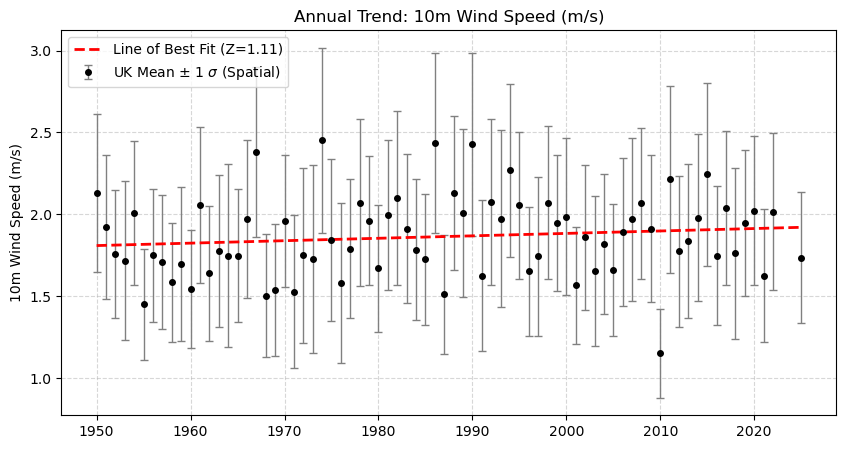

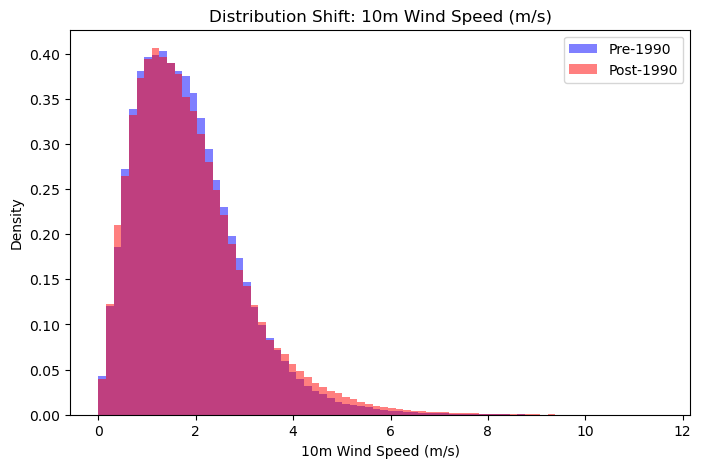

In [7]:
plot_variable(ds, 'wind_speed')

## Dewpoint Temperature


--- Plotting Dewpoint Temperature (°C) ---


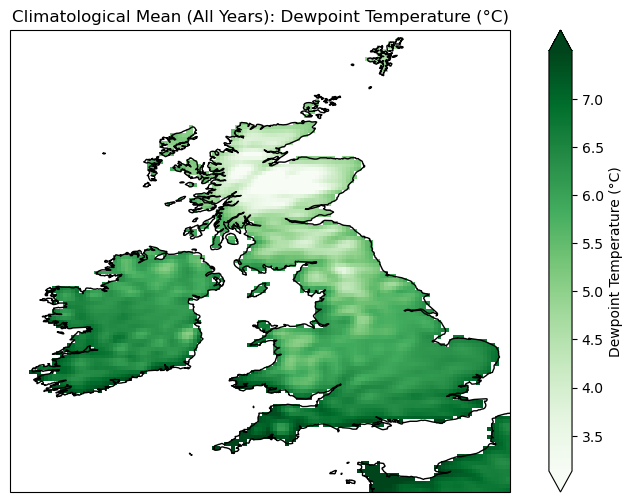

Trend (Slope): 0.0162 per year
Standard Error: 0.0024
Z-Score: 6.78 	 (Values > 1.96 or < -1.96 indicate >95% confidence)


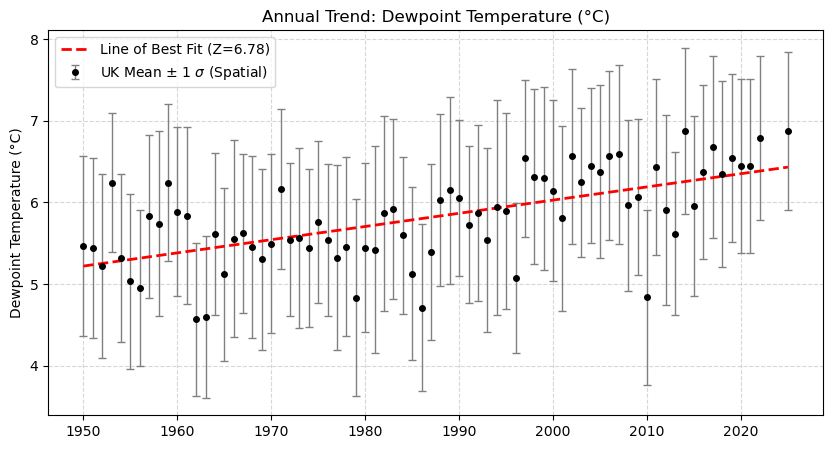

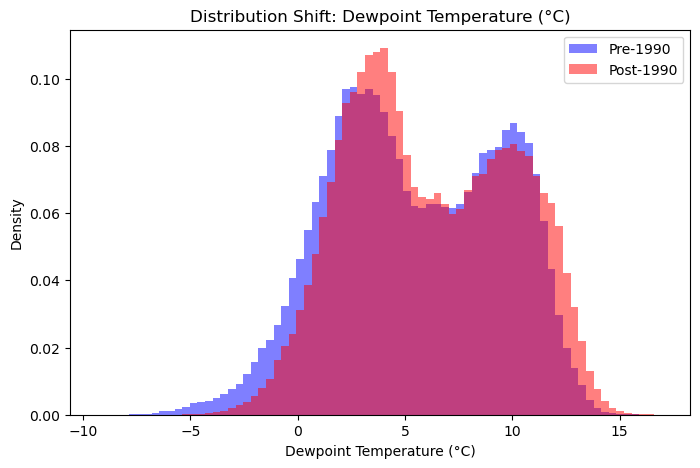

In [8]:
plot_variable(ds, 'd2m')

## Evaporation


--- Plotting Total Evaporation (mm) ---


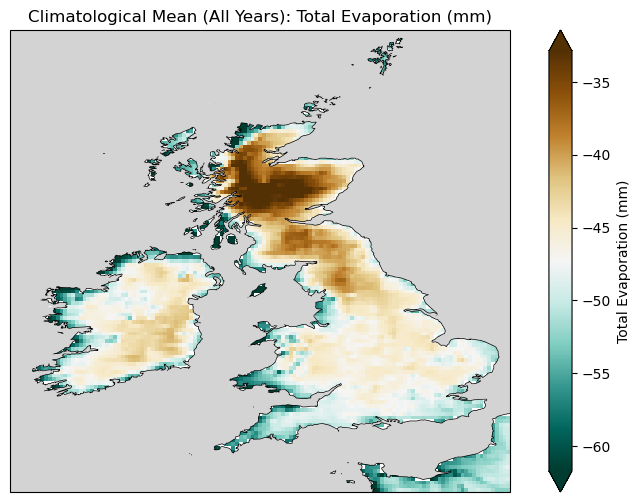

Trend (Slope): -0.1679 per year
Standard Error: 0.0270
Z-Score: -6.21 	 (Values > 1.96 or < -1.96 indicate >95% confidence)


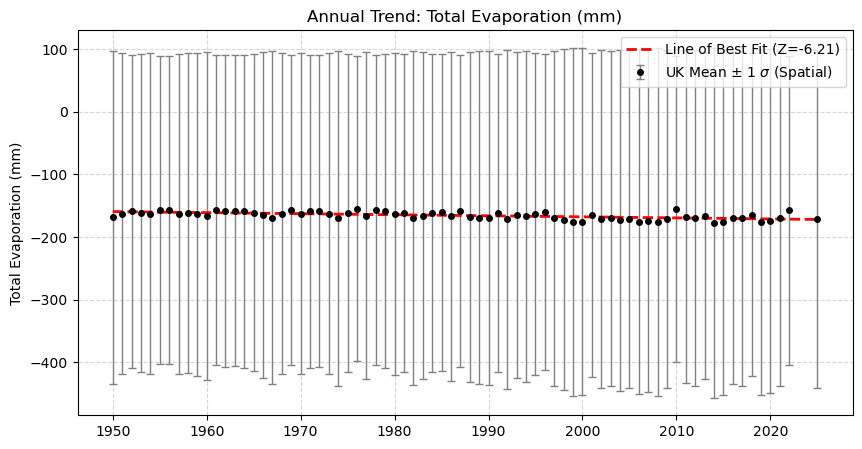

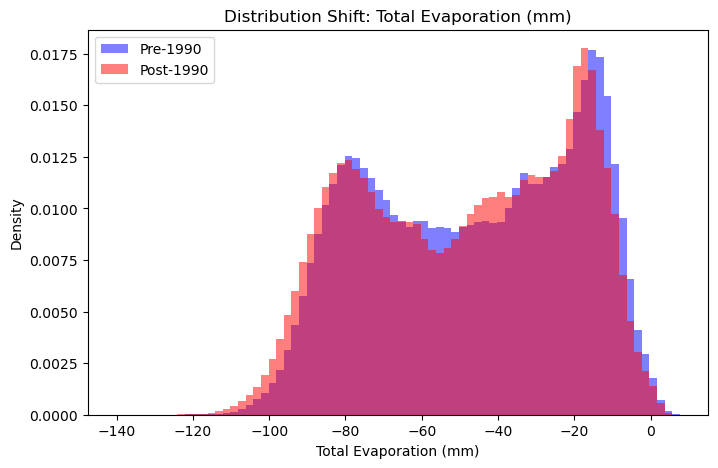

In [9]:
plot_variable(ds, 'e')

## Runoff


--- Plotting Runoff (mm) ---


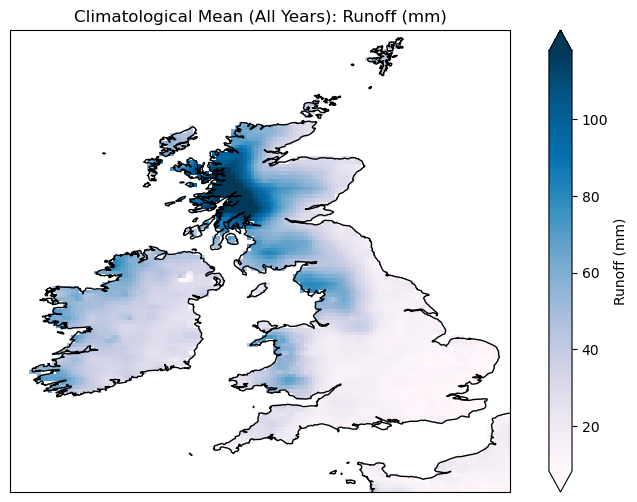

Trend (Slope): 0.4960 per year
Standard Error: 0.1145
Z-Score: 4.33 	 (Values > 1.96 or < -1.96 indicate >95% confidence)


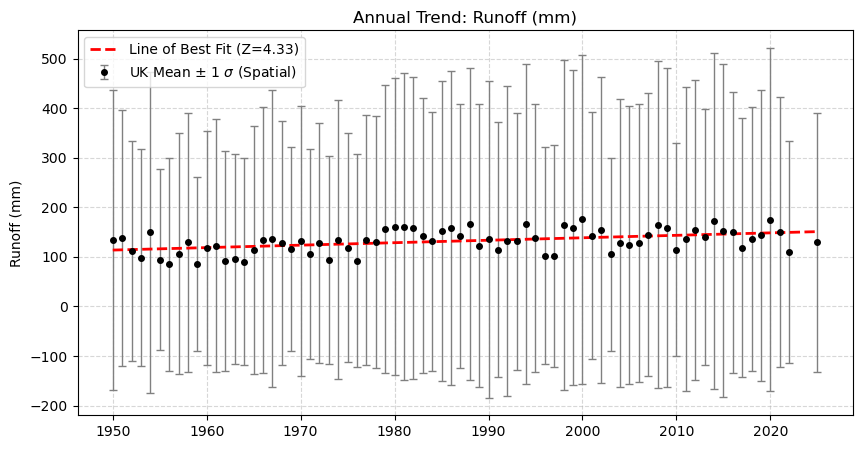

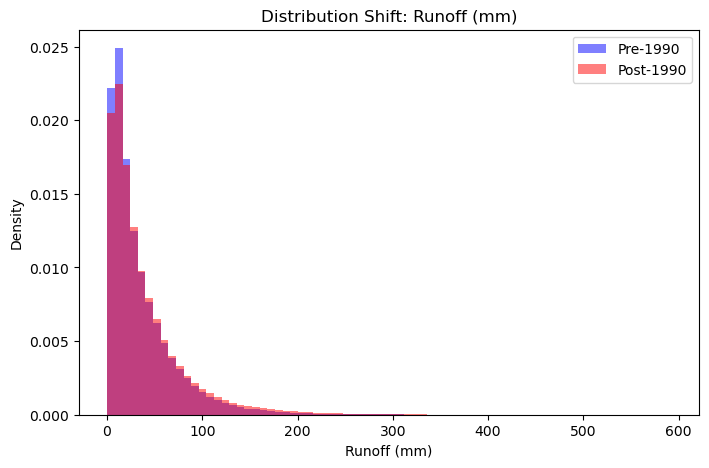

In [10]:
plot_variable(ds, 'ro')

## Snowfall


--- Plotting Snowfall (mm water eq) ---


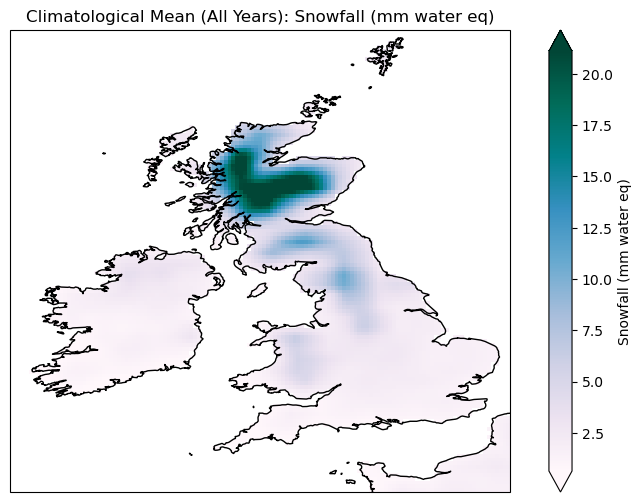

Trend (Slope): -0.0830 per year
Standard Error: 0.0270
Z-Score: -3.08 	 (Values > 1.96 or < -1.96 indicate >95% confidence)


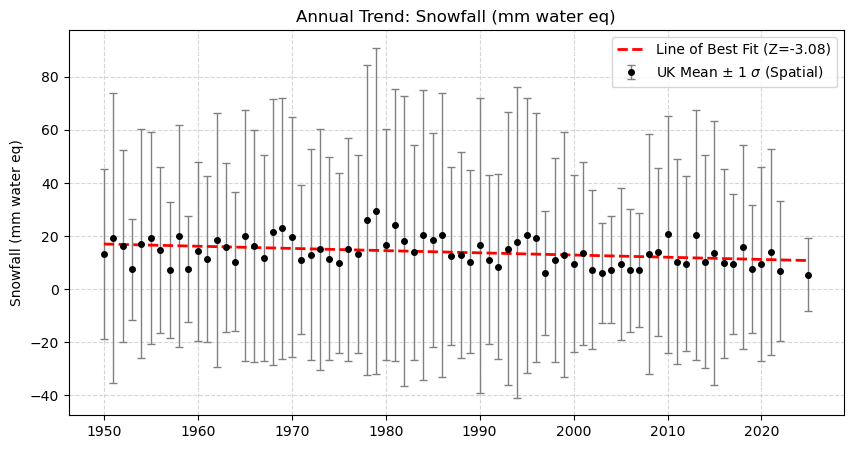

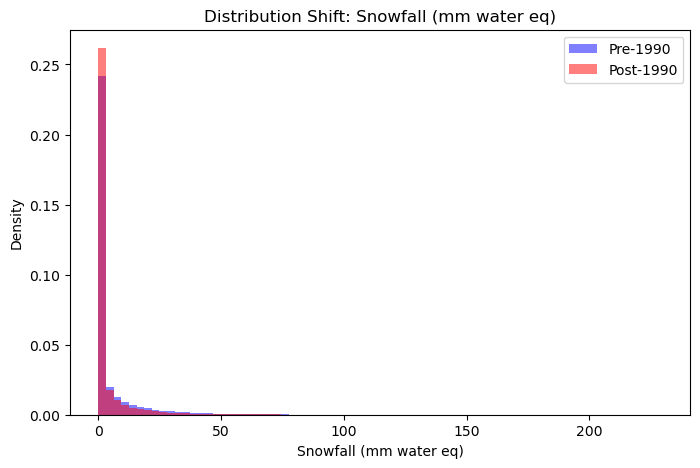

In [11]:
plot_variable(ds, 'sf')

## Soil Water


--- Plotting Volumetric Soil Water (m3/m3) ---


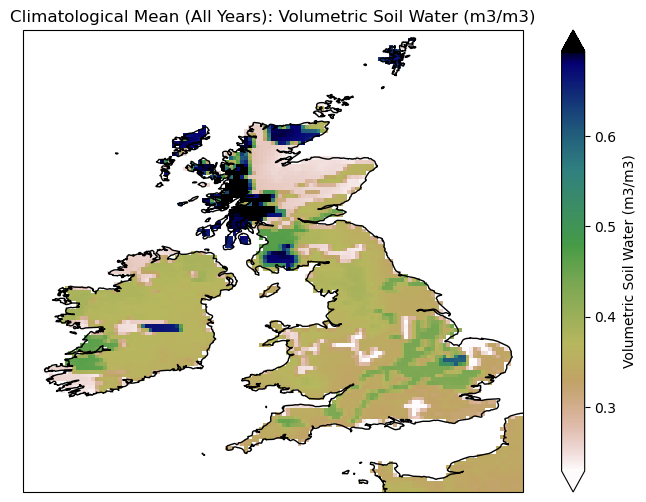

Trend (Slope): 0.0001 per year
Standard Error: 0.0001
Z-Score: 1.21 	 (Values > 1.96 or < -1.96 indicate >95% confidence)


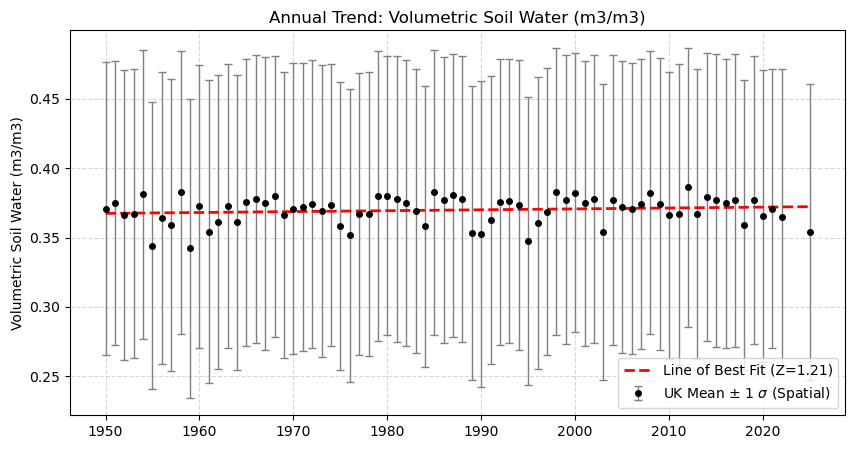

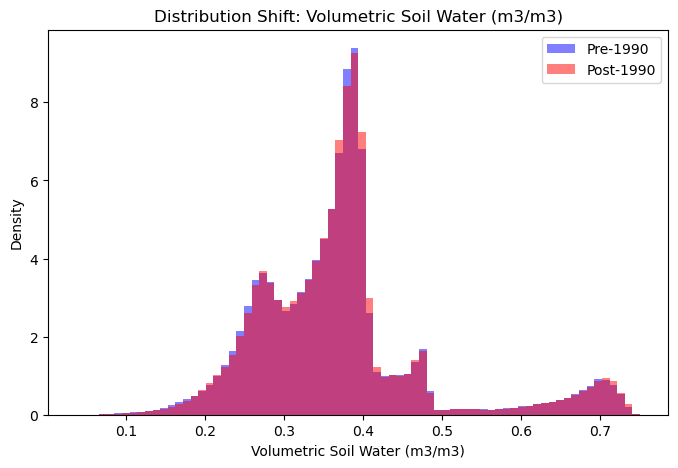

In [12]:
plot_variable(ds, 'swvl1')

## Surface Pressure


--- Plotting Surface Pressure (hPa) ---


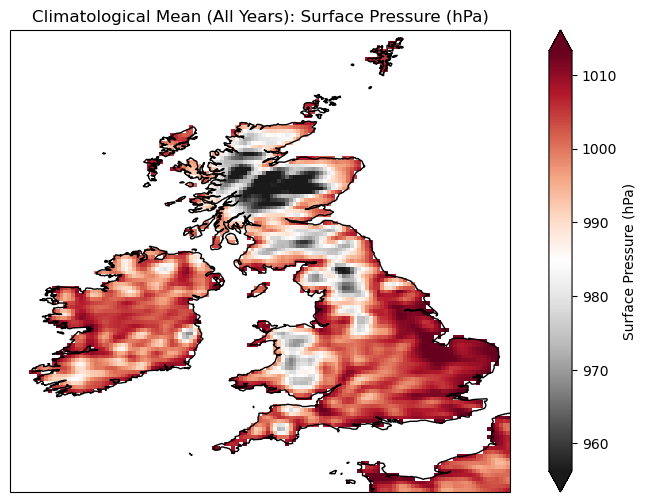

Trend (Slope): 0.0003 per year
Standard Error: 0.0074
Z-Score: 0.04 	 (Values > 1.96 or < -1.96 indicate >95% confidence)


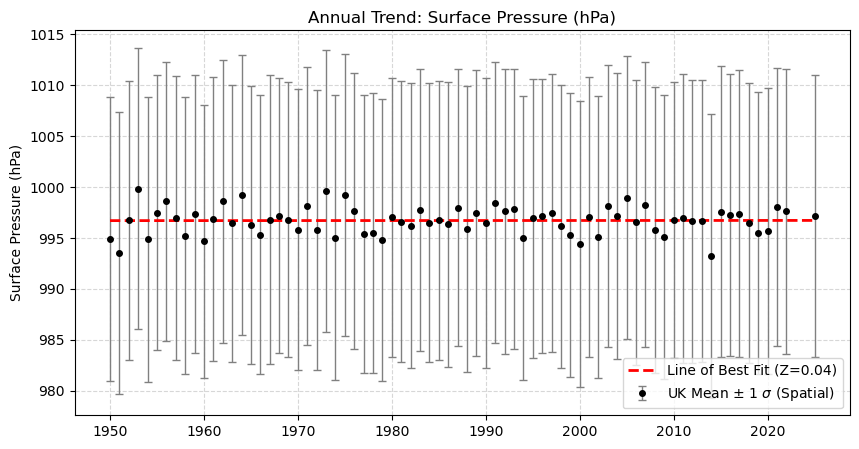

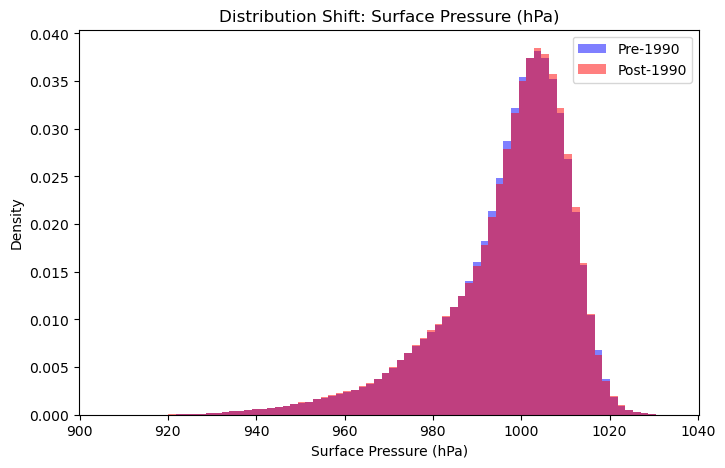

In [13]:
plot_variable(ds, 'sp')